In [1]:
import subprocess

libraries = [
    'pandas',
    'numpy',
    'seaborn',
    'matplotlib',
    'scikit-learn',
    'scipy'
]

for lib in libraries:
    result = subprocess.run(
        ['pip', 'install', lib, '--quiet'],
        capture_output=True, text=True
    )
    print(f"{lib:<20} ✓")

print("\nAll libraries installed successfully")


pandas               ✓
numpy                ✓
seaborn              ✓
matplotlib           ✓
scikit-learn         ✓
scipy                ✓

All libraries installed successfully


In [2]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Stats
from scipy import stats

# Scikit-learn (imported now, used in future sessions)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_rows', 100)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi']      = 120
plt.rcParams['figure.figsize']  = (12, 5)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize']   = 13

print("All imports successful ✓")
print(f"Pandas     : {pd.__version__}")
print(f"Numpy      : {np.__version__}")
print(f"Seaborn    : {sns.__version__}")

All imports successful ✓
Pandas     : 2.3.3
Numpy      : 2.3.5
Seaborn    : 0.13.2


In [3]:
# Load all source files
orders      = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments    = pd.read_csv('olist_order_payments_dataset.csv')
customers   = pd.read_csv('olist_customers_dataset.csv')
products    = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')
reviews     = pd.read_csv('olist_order_reviews_dataset.csv')
sellers     = pd.read_csv('olist_sellers_dataset.csv')

print("All source files loaded ✓")
for name, df in [('orders',orders),('order_items',order_items),
                 ('payments',payments),('customers',customers),
                 ('products',products),('reviews',reviews),('sellers',sellers)]:
    print(f"  {name:<15}: {len(df):>7,} rows")

All source files loaded ✓
  orders         :  99,441 rows
  order_items    : 112,650 rows
  payments       : 103,886 rows
  customers      :  99,441 rows
  products       :  32,951 rows
  reviews        :  99,224 rows
  sellers        :   3,095 rows


In [4]:
# Step 1 — merge product translations
products = products.merge(translation, on='product_category_name', how='left')

# Step 2 — aggregate order_items to order level
items_agg = order_items.groupby('order_id').agg(
    total_item_revenue = ('price',         'sum'),
    total_freight      = ('freight_value', 'sum'),
    total_items        = ('order_item_id', 'count'),
    product_id         = ('product_id',    'first'),
    seller_id          = ('seller_id',     'first')
).reset_index()
items_agg['total_order_revenue'] = items_agg['total_item_revenue'] + items_agg['total_freight']

# Step 3 — aggregate payments to order level
payments_agg = payments.groupby('order_id').agg(
    payment_type         = ('payment_type',         'first'),
    payment_installments = ('payment_installments', 'max'),
    payment_value        = ('payment_value',        'sum')
).reset_index()

# Step 4 — aggregate reviews to order level
reviews_agg = reviews.groupby('order_id')['review_score'].mean().reset_index()

# Step 5 — join everything together
amt = (orders
    .merge(items_agg,    on='order_id',   how='left')
    .merge(customers,    on='customer_id', how='left')
    .merge(payments_agg, on='order_id',   how='left')
    .merge(reviews_agg,  on='order_id',   how='left')
    .merge(products[['product_id','product_category_name_english']],
                         on='product_id', how='left')
    .merge(sellers[['seller_id','seller_state']],
                         on='seller_id',  how='left')
)

print(f"AMT built ✓")
print(f"Shape  : {amt.shape}")
print(f"Columns: {amt.columns.tolist()}")

AMT built ✓
Shape  : (99441, 24)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'total_item_revenue', 'total_freight', 'total_items', 'product_id', 'seller_id', 'total_order_revenue', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_type', 'payment_installments', 'payment_value', 'review_score', 'product_category_name_english', 'seller_state']


In [5]:
# Parse all date columns
date_cols = ['order_purchase_timestamp','order_approved_at',
             'order_delivered_carrier_date','order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    amt[col] = pd.to_datetime(amt[col])

# Discount depth columns
amt['freight_pct']     = (amt['total_freight'] /
                           amt['total_order_revenue'] * 100).round(2)

amt['discount_depth']  = (1 - (amt['payment_value'] /
                                amt['total_order_revenue'])).round(4)

# Delivery metrics
amt['delivery_days']   = (amt['order_delivered_customer_date'] -
                           amt['order_purchase_timestamp']).dt.days

amt['delay_days']      = (amt['order_delivered_customer_date'] -
                           amt['order_estimated_delivery_date']).dt.days

# Binary flags
amt['is_delayed']      = (amt['delay_days']      > 0).astype(int)
amt['is_canceled']     = (amt['order_status'] == 'canceled').astype(int)
amt['is_delivered']    = (amt['order_status'] == 'delivered').astype(int)
amt['is_credit_card']  = (amt['payment_type'] == 'credit_card').astype(int)
amt['is_high_install'] = (amt['payment_installments'] > 6).astype(int)

# Month column for time series
amt['order_month']     = amt['order_purchase_timestamp'].dt.to_period('M')

print("All derived columns created ✓")
print(f"\nFinal AMT shape: {amt.shape}")
print(f"\nNew columns added:")
new_cols = ['freight_pct','discount_depth','delivery_days',
            'delay_days','is_delayed','is_canceled','is_delivered',
            'is_credit_card','is_high_install','order_month']
for c in new_cols:
    print(f"  {c:<25}: {amt[c].dtype}  | nulls: {amt[c].isnull().sum()}")

All derived columns created ✓

Final AMT shape: (99441, 34)

New columns added:
  freight_pct              : float64  | nulls: 775
  discount_depth           : float64  | nulls: 776
  delivery_days            : float64  | nulls: 2965
  delay_days               : float64  | nulls: 2965
  is_delayed               : int64  | nulls: 0
  is_canceled              : int64  | nulls: 0
  is_delivered             : int64  | nulls: 0
  is_credit_card           : int64  | nulls: 0
  is_high_install          : int64  | nulls: 0
  order_month              : period[M]  | nulls: 0


In [6]:
print("=== AMT Health Check ===")
print(f"Total orders           : {len(amt):,}")
print(f"Delivered orders       : {amt['is_delivered'].sum():,}")
print(f"Canceled orders        : {amt['is_canceled'].sum():,}")
print(f"Orders with freight    : {(amt['total_freight'] > 0).sum():,}")
print(f"Avg freight pct        : {amt['freight_pct'].mean():.2f}%")
print(f"Avg review score       : {amt['review_score'].mean():.2f}")
print(f"Avg delivery days      : {amt['delivery_days'].mean():.1f} days")
print(f"\nNull counts (key cols):")
key_cols = ['total_order_revenue','payment_value','freight_pct',
            'discount_depth','review_score','product_category_name_english']
print(amt[key_cols].isnull().sum())

=== AMT Health Check ===
Total orders           : 99,441
Delivered orders       : 96,478
Canceled orders        : 625
Orders with freight    : 98,328
Avg freight pct        : 20.88%
Avg review score       : 4.09
Avg delivery days      : 12.1 days

Null counts (key cols):
total_order_revenue               775
payment_value                       1
freight_pct                       775
discount_depth                    776
review_score                      768
product_category_name_english    2212
dtype: int64


In [7]:
print("""
DISCOUNT DEPTH — Definition for Olist Dataset
==============================================

Since Olist has no explicit discount column, we derive
discount depth from two signals:

1. FREIGHT PCT  = total_freight / total_order_revenue × 100
   → How much of the order cost is shipping
   → High freight % = customer is paying a large shipping burden
   → Range: 0% to 95.55% | Mean: 20.88%

2. DISCOUNT DEPTH = 1 - (payment_value / total_order_revenue)
   → Positive value = customer paid LESS than order total (voucher used)
   → Zero = customer paid exact amount
   → Negative = customer paid MORE (multi-payment rounding)
   → 98,275 orders have 0 discount (no voucher used)
   →    103 orders have positive discount (voucher applied)
   →    287 orders have negative discount (rounding artifact)
""")


DISCOUNT DEPTH — Definition for Olist Dataset

Since Olist has no explicit discount column, we derive
discount depth from two signals:

1. FREIGHT PCT  = total_freight / total_order_revenue × 100
   → How much of the order cost is shipping
   → High freight % = customer is paying a large shipping burden
   → Range: 0% to 95.55% | Mean: 20.88%

2. DISCOUNT DEPTH = 1 - (payment_value / total_order_revenue)
   → Positive value = customer paid LESS than order total (voucher used)
   → Zero = customer paid exact amount
   → Negative = customer paid MORE (multi-payment rounding)
   → 98,275 orders have 0 discount (no voucher used)
   →    103 orders have positive discount (voucher applied)
   →    287 orders have negative discount (rounding artifact)



In [8]:
eda_cols = amt[['freight_pct', 'discount_depth',
                'total_item_revenue', 'total_freight',
                'payment_value', 'total_order_revenue']].copy()

print("=== Summary Statistics ===")
print(eda_cols.describe().T.to_string())

print("\n=== Freight PCT Percentiles ===")
pcts = [10, 25, 50, 75, 90, 95, 99]
for p in pcts:
    val = np.percentile(amt['freight_pct'].dropna(), p)
    print(f"  P{p:<3}: {val:.2f}%")

print("\n=== Discount Depth Breakdown ===")
dd = amt['discount_depth'].dropna()
print(f"  Zero discount (no voucher)  : {(dd == 0).sum():,} orders")
print(f"  Positive discount (voucher) : {(dd > 0).sum():,} orders")
print(f"  Negative (rounding artifact): {(dd < 0).sum():,} orders")
print(f"  Max voucher discount        : {dd.max():.2%}")
print(f"  Avg when voucher applied    : {dd[dd > 0].mean():.2%}")

=== Summary Statistics ===
                       count   mean    std   min   25%    50%    75%      max
freight_pct         98666.00  20.88  12.57  0.00 11.65  18.33  27.55    95.55
discount_depth      98665.00  -0.00   0.01 -0.41  0.00   0.00   0.00     0.29
total_item_revenue  98666.00 137.75 210.65  0.85 45.90  86.90 149.90 13440.00
total_freight       98666.00  22.82  21.65  0.00 13.85  17.17  24.04  1794.96
payment_value       99440.00 160.99 221.95  0.00 62.01 105.29 176.97 13664.08
total_order_revenue 98666.00 160.58 220.47  9.59 61.98 105.29 176.87 13664.08

=== Freight PCT Percentiles ===
  P10 : 7.23%
  P25 : 11.65%
  P50 : 18.33%
  P75 : 27.55%
  P90 : 38.37%
  P95 : 45.63%
  P99 : 59.38%

=== Discount Depth Breakdown ===
  Zero discount (no voucher)  : 98,275 orders
  Positive discount (voucher) : 103 orders
  Negative (rounding artifact): 287 orders
  Max voucher discount        : 29.04%
  Avg when voucher applied    : 1.64%


C:\Users\seela\AppData\Local\Temp\ipykernel_14572\134810073.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=state_data, x='customer_state', y='freight_pct',


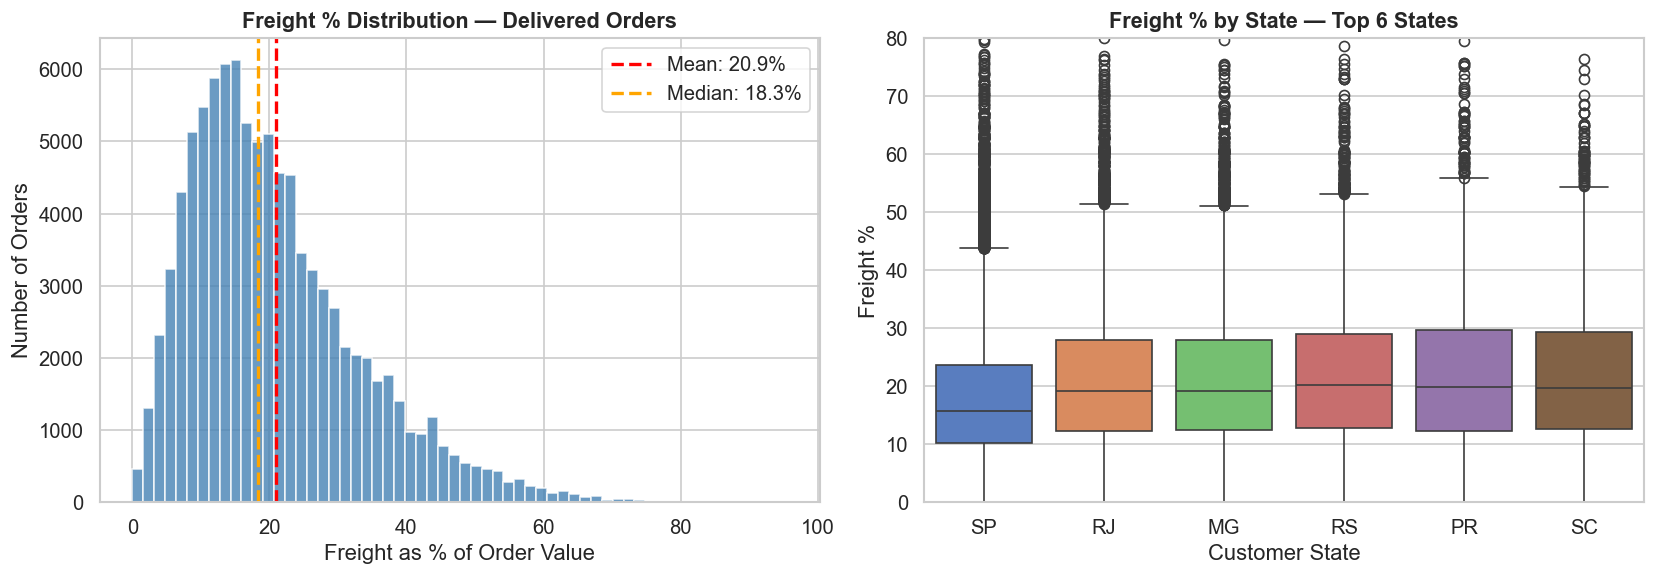

Key insight: Mean freight burden is 20.9%
SP (largest market) tends to have lower freight than remote states


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
delivered = amt[amt['is_delivered'] == 1]['freight_pct'].dropna()

axes[0].hist(delivered, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(delivered.mean(),   color='red',    linestyle='--', linewidth=2,
                label=f'Mean: {delivered.mean():.1f}%')
axes[0].axvline(delivered.median(), color='orange', linestyle='--', linewidth=2,
                label=f'Median: {delivered.median():.1f}%')
axes[0].set_title('Freight % Distribution — Delivered Orders')
axes[0].set_xlabel('Freight as % of Order Value')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

# Box plot by customer state (top 6 states)
top_states = amt['customer_state'].value_counts().head(6).index
state_data = amt[amt['customer_state'].isin(top_states)]

sns.boxplot(data=state_data, x='customer_state', y='freight_pct',
            order=top_states, palette='muted', ax=axes[1])
axes[1].set_title('Freight % by State — Top 6 States')
axes[1].set_xlabel('Customer State')
axes[1].set_ylabel('Freight %')
axes[1].set_ylim(0, 80)

plt.tight_layout()
plt.show()

print(f"Key insight: Mean freight burden is {delivered.mean():.1f}%")
print(f"SP (largest market) tends to have lower freight than remote states")